## Ejercicio 3

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [4]:
def mascara_rayo(n, direccion, s):
    alpha= direccion[0]
    beta= direccion[1]
    matriz= np.zeros((n,n), dtype=int)
    for i in range(n):
        for j in range (n):
            if alpha * i + beta*j == s:
                matriz[i][j]=1
    return matriz

### Inciso a)

In [5]:
X_fantoma = np.array([ 
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 
[0.0, 0.0, 0.8, 0.3, 0.3, 0.3, 0.0, 0.0], 
[0.0, 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0.0], 
[0.0, 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0.0], 
[0.0, 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0.0], 
[0.0, 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0.0], 
[0.0, 0.0, 0.3, 0.3, 0.3, 0.5, 0.0, 0.0], 
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], ], dtype=float)

x_fantoma = X_fantoma.reshape(-1)

def matriz_proyeccion(n, direcciones):
    filas_A = []

    for k in range(len(direcciones)):
        alfa = direcciones[k][0]
        beta = direcciones[k][1]

        valores_s = set()

        for i in range(n):
            for j in range(n):
                s = alfa * i + beta * j
                valores_s.add(s)

        valores_s = sorted(valores_s)

        for s in valores_s:
            mascara = mascara_rayo(n, direcciones[k], s)
            fila = mascara.reshape(-1)
            filas_A.append(fila)

    A = np.array(filas_A)

    return A


### Inciso b)

In [6]:
def matriz_proyeccion_y_rayo(n, direcciones):
    filas_A = []
    rayos = []

    for k in range(len(direcciones)):
        # Guardamos las coordenadas alfa, beta de cada tupla del vector direcciones
        alfa= direcciones[k][0]
        beta = direcciones[k][1] 
        valores_s = set() # Inicializamos el conjunto valores_s donde gaurdamos los valores s ordenados

        for i in range(n):
            for j in range(n):
                # Para esa direccion calculamos el valor s
                s = alfa * i + beta * j
                valores_s.add(s) # Agregamos ese valor s al conjunto de valores_s

        valores_s = sorted(valores_s) # Ordenamos los valores del conjunto

        # Para cada valor del conjunto valores_s
        for s in valores_s:
            # Construimos su mascara tomando la direccion y su valor correspondiente s
            mascara = mascara_rayo(n, direcciones[k], s)
            fila = mascara.reshape(-1) #Vectorizamos la mascara para luego convertirlo en fila de la matriz A
            filas_A.append(fila) #Agregamos la fila a la matriz A
            rayos.append((direcciones[k], s))

    A = np.array(filas_A)
    return A, rayos

### Inciso c)

In [8]:
matriz_proyeccion(8,[(1,0),(0,1)])

array([[1, 1, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 1]], shape=(16, 64))

Por el **shape=(16,64)** podemos corroborar que el tamaño de la matriz A es de 16x64, siendo 16 la cantidad de rayos

### Inciso d)

Cada fila de *A* es la versión vectorizada de la máscara generada por un rayo *r*. Cada columna de *A* representa un píxel de la imagen y muestra en qué rayos participa ese píxel.

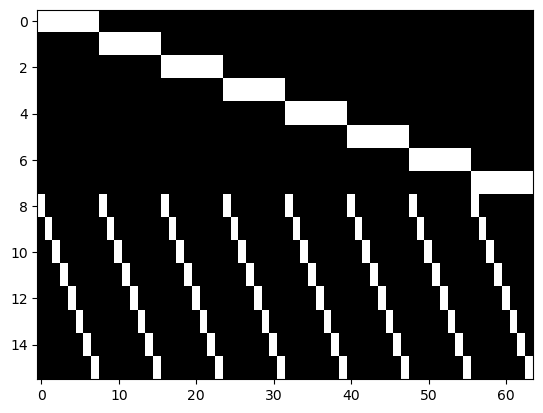

In [12]:
A = matriz_proyeccion(8, [(1, 0), (0, 1)])
plt.imshow(A, cmap="gray", aspect="auto")
